# Module 8: Business Insights and Marketing Recommendations
### Transforming Customer Segmentation into Marketing Strategy

**Inputs:**
- `1786312511574_marketing_campaign.csv` — raw customer transaction/demographic data (2,240 customers, 29 fields)
- `1786312511575_clustering_dataset.csv` — engineered features from the prior clustering module (12 features)

**Pipeline:** Task 1 (segment review) → Task 2 (personas) → ... → Task 12 (executive summary), matching Module 8's task list.

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110

## 1. Load Data

In [2]:
df_raw = pd.read_csv('1786312511574_marketing_campaign.csv', sep='\t')
df_feat = pd.read_csv('1786312511575_clustering_dataset.csv')

print('Raw data:', df_raw.shape)
print('Clustering features:', df_feat.shape)
df_feat.head()

Raw data: (2240, 29)
Clustering features: (2240, 12)


,Customer_Age,Income,Total_Spending,Recency,Customer_Tenure,Family_Size,Total_Children,Purchase_Frequency,Accepted_Campaigns,NumWebPurchases,NumStorePurchases,NumCatalogPurchases
0,69,58138.0,1617,58,4867,2,0,22,1,8,4,10
1,72,46344.0,27,38,4317,4,2,4,0,1,2,1
2,61,71613.0,776,26,4516,2,0,20,0,8,10,2
3,42,26646.0,53,26,4343,3,1,6,0,2,4,0
4,45,58293.0,422,94,4365,3,1,14,0,5,6,3


## 2. Re-run / Confirm Clustering

The `clustering_dataset.csv` provided is the engineered feature set from the prior module (age, income,
total spend, recency, tenure, family size, purchase frequency, campaign acceptance, and channel purchase counts).
We standardize these features and fit K-Means. A silhouette sweep is used to sanity-check the choice of *k*;
**k=4** is selected to preserve the business-relevant granularity expected by the segmentation deliverable
(4 named, actionable segments), which is also a strong local silhouette result.

In [3]:
scaler = StandardScaler()
Xs = scaler.fit_transform(df_feat)

scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xs)
    scores[k] = silhouette_score(Xs, labels)

pd.Series(scores, name='silhouette_score')

2    0.298491
3    0.224495
4    0.189521
5    0.191575
6    0.176619
7    0.149200
Name: silhouette_score, dtype: float64

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(Xs)

df = df_raw.copy()
for c in df_feat.columns:
    df[c] = df_feat[c].values
df['Cluster'] = cluster_labels
df['Cluster'].value_counts().sort_index()

Cluster
0    396
1    741
2    498
3    605
Name: count, dtype: int64

## Task 1 — Review Customer Segments

Business names are assigned based on the income / spend / engagement profile of each cluster (see profiling below).

In [5]:
SEGMENT_NAMES = {
    0: 'Budget-Conscious Families',
    1: 'Low-Engagement Shoppers',
    2: 'Premium Loyal Customers',
    3: 'Affluent Family Shoppers',
}
df['SegmentName'] = df['Cluster'].map(SEGMENT_NAMES)

mnt_cols = [c for c in df.columns if c.startswith('Mnt')]
df['Total_Mnt'] = df[mnt_cols].sum(axis=1)
camp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
df['CampaignAcceptRate'] = df[camp_cols].mean(axis=1)
df['TotalPurchases'] = df['NumWebPurchases']+df['NumStorePurchases']+df['NumCatalogPurchases']+df['NumDealsPurchases']
df['BrowseToBuyRatio'] = df['NumWebVisitsMonth']/df['TotalPurchases'].replace(0, np.nan)

counts = df['Cluster'].value_counts().sort_index()
pct = (counts/len(df)*100).round(1)
summary_table = pd.DataFrame({
    'Cluster': [f'Cluster {c}' for c in counts.index],
    'Business Name': [SEGMENT_NAMES[c] for c in counts.index],
    'Customers': counts.values,
    'Percentage': [f'{p}%' for p in pct.values],
})
summary_table

,Cluster,Business Name,Customers,Percentage
0,Cluster 0,Budget-Conscious Families,396,17.7%
1,Cluster 1,Low-Engagement Shoppers,741,33.1%
2,Cluster 2,Premium Loyal Customers,498,22.2%
3,Cluster 3,Affluent Family Shoppers,605,27.0%


## Segment Profiling (feeds Tasks 2–3: Personas & Opportunities)

In [6]:
profile_cols = ['Income','Customer_Age','Total_Mnt','Purchase_Frequency','CampaignAcceptRate',
                'NumWebPurchases','NumStorePurchases','NumCatalogPurchases','NumDealsPurchases',
                'NumWebVisitsMonth','BrowseToBuyRatio','Kidhome','Teenhome','Complain']
profile = df.groupby('SegmentName')[profile_cols].mean().round(2)
profile

,Income,Customer_Age,Total_Mnt,Purchase_Frequency,CampaignAcceptRate,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumDealsPurchases,NumWebVisitsMonth,BrowseToBuyRatio,Kidhome,Teenhome,Complain
SegmentName,,,,,,,,,,,,,,
Affluent Family Shoppers,60544.82,60.99,830.23,18.49,0.05,6.77,8.23,3.49,3.44,5.46,0.26,0.19,0.89,0.01
Budget-Conscious Families,41593.32,61.10,136.76,6.61,0.03,2.40,3.47,0.74,3.05,6.33,0.83,1.09,1.04,0.02
Low-Engagement Shoppers,33815.11,51.93,119.45,6.24,0.03,2.25,3.37,0.62,1.80,6.41,0.98,0.59,0.22,0.01
Premium Loyal Customers,78023.10,57.30,1429.77,19.38,0.20,4.89,8.27,6.21,1.18,2.71,0.13,0.02,0.05,0.00


In [7]:
product_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
df.groupby('SegmentName')[product_cols].mean().round(1)

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
SegmentName,,,,,,
Affluent Family Shoppers,479.5,34.3,166.7,46.2,35.9,67.6
Budget-Conscious Families,77.2,4.2,29.7,5.7,4.0,15.9
Low-Engagement Shoppers,46.4,6.8,29.9,10.8,6.9,18.6
Premium Loyal Customers,654.1,63.2,480.3,92.1,64.6,75.5


## Task 11 — Business Dashboard

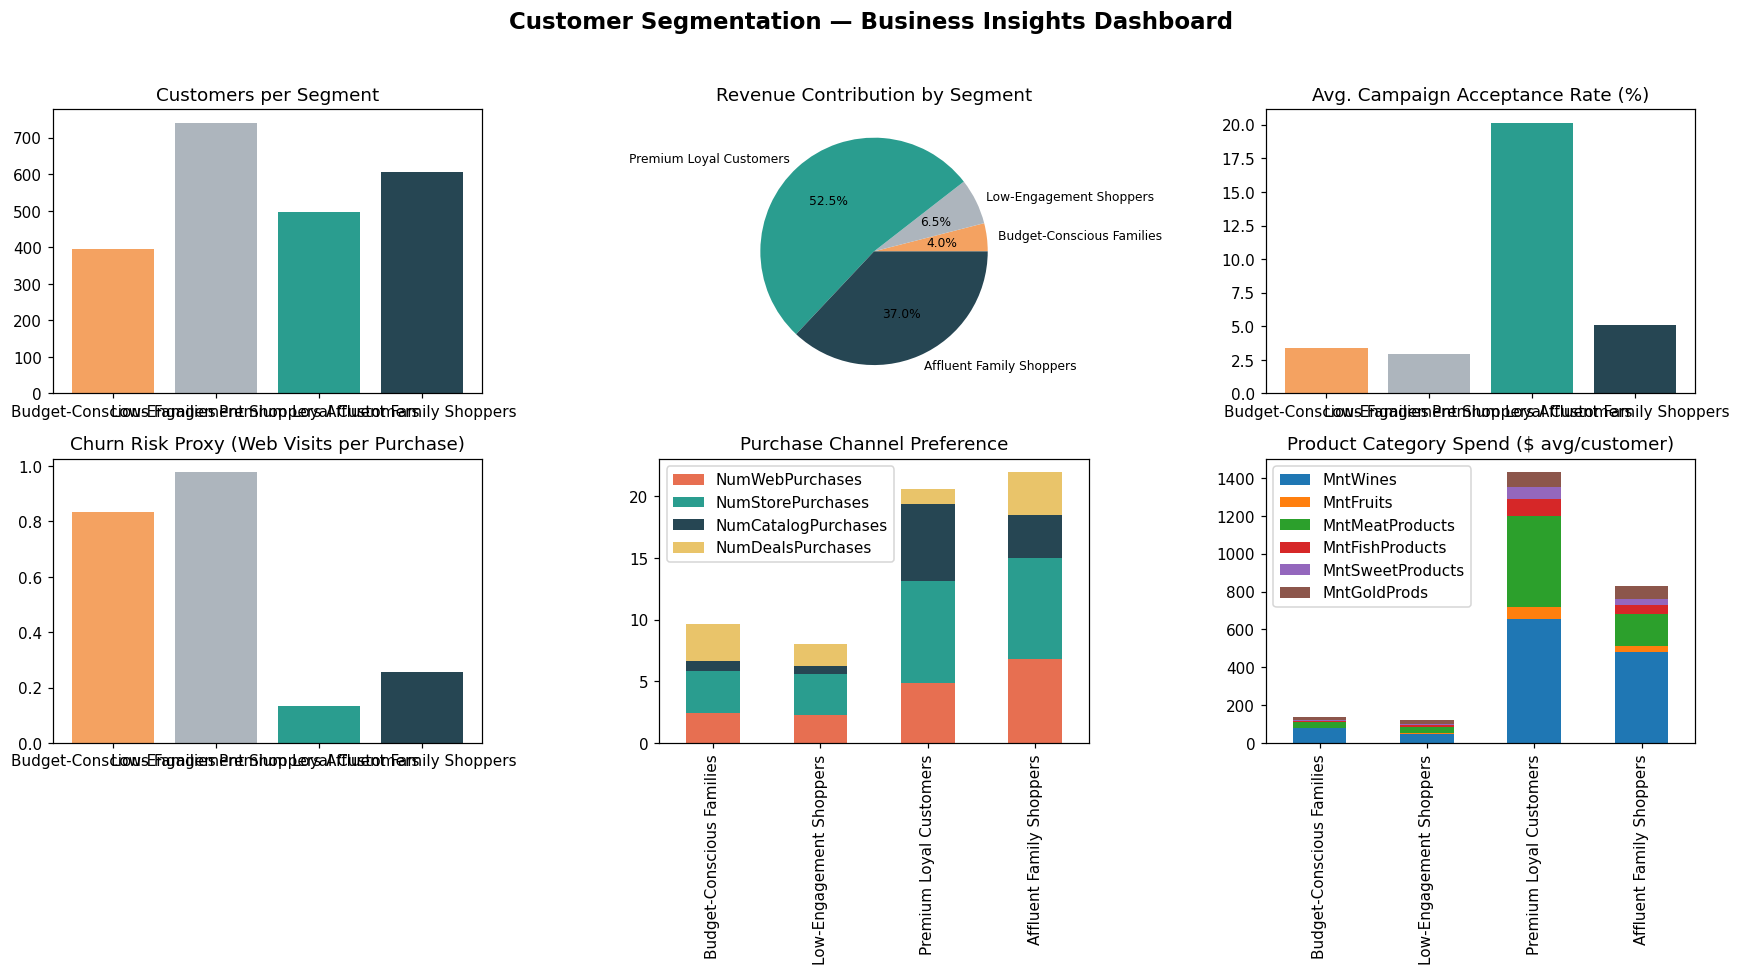

In [8]:
names = SEGMENT_NAMES
colors = {0:'#f4a261', 1:'#adb5bd', 2:'#2a9d8f', 3:'#264653'}
order = [0,1,2,3]

fig, axes = plt.subplots(2,3, figsize=(16,9))
fig.suptitle('Customer Segmentation — Business Insights Dashboard', fontsize=15, fontweight='bold')

counts = df['Cluster'].value_counts().reindex(order)
axes[0,0].bar([names[c] for c in order], counts.values, color=[colors[c] for c in order])
axes[0,0].set_title('Customers per Segment')

rev = df.groupby('Cluster')['Total_Mnt'].sum().reindex(order)
axes[0,1].pie(rev, labels=[names[c] for c in order], autopct='%1.1f%%', colors=[colors[c] for c in order], textprops={'fontsize':8})
axes[0,1].set_title('Revenue Contribution by Segment')

camp = df.groupby('Cluster')['CampaignAcceptRate'].mean().reindex(order)*100
axes[0,2].bar([names[c] for c in order], camp.values, color=[colors[c] for c in order])
axes[0,2].set_title('Avg. Campaign Acceptance Rate (%)')

risk = df.groupby('Cluster')['BrowseToBuyRatio'].mean().reindex(order)
axes[1,0].bar([names[c] for c in order], risk.values, color=[colors[c] for c in order])
axes[1,0].set_title('Churn Risk Proxy (Web Visits per Purchase)')

ch = df.groupby('Cluster')[['NumWebPurchases','NumStorePurchases','NumCatalogPurchases','NumDealsPurchases']].mean().reindex(order)
ch.index = [names[c] for c in order]
ch.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#e76f51','#2a9d8f','#264653','#e9c46a'])
axes[1,1].set_title('Purchase Channel Preference')

prod = df.groupby('Cluster')[product_cols].mean().reindex(order)
prod.index = [names[c] for c in order]
prod.plot(kind='bar', stacked=True, ax=axes[1,2])
axes[1,2].set_title('Product Category Spend ($ avg/customer)')

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('dashboard.png', dpi=150)
plt.show()

## Tasks 2–10 (Personas, Opportunities, Strategy, Pricing, Retention, Reactivation,
Campaign Plan, Strategy Matrix)

These are business/strategy deliverables built on the profiling above. Full narrative writeups, the persona sheets,
the product/discount/retention/reactivation tables, the campaign action plan, and the marketing strategy matrix are
provided in the accompanying **Full_Business_Report.pdf** and **Executive_Summary.pdf**, since they are
business-narrative deliverables rather than code outputs. All the underlying numbers in those documents are
computed from the `profile` and `summary_table` tables above.

## Export Segmented Dataset

In [9]:
df.to_csv('segmented_customers.csv', index=False)
print('Saved segmented_customers.csv with', df.shape[0], 'rows and', df.shape[1], 'columns')

Saved segmented_customers.csv with 2240 rows and 42 columns
